## Case Study D – KPI `da403e4e3f87c9e0`: Data overview

This notebook performs a structured data overview for Case Study D, using KPI `da403e4e3f87c9e0` from the AIOps 2018 anomaly detection dataset (`Preliminary_dataset/train.csv`).


### Loading the stacked KPI dataset and filtering Case Study D

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [5]:
# Location of the preliminary training data (all KPIs combined)
train_file_path = "../data/KPI-Anomaly-Detection-master/Preliminary_dataset/train.csv"

# Load the full training table
kpi_train_full = pd.read_csv(train_file_path)

# KPI selected for Case Study D
case_d_kpi_id = "da403e4e3f87c9e0"

# Keep only rows that belong to the selected KPI
case_d_data = kpi_train_full[kpi_train_full["KPI ID"] == case_d_kpi_id].copy()

# Ensure the series is ordered in time
case_d_data = case_d_data.sort_values("timestamp").reset_index(drop=True)

# Create a readable datetime column from the Unix timestamp
case_d_data["time"] = pd.to_datetime(case_d_data["timestamp"], unit="s")

# Arrange columns so the time information appears first
case_d_data = case_d_data[["time", "timestamp", "value", "label", "KPI ID"]]

case_d_data.head()


,time,timestamp,value,label,KPI ID
0,2017-04-30 16:00:00,1493568000,1.666667,0,da403e4e3f87c9e0
1,2017-04-30 16:01:00,1493568060,1.833333,0,da403e4e3f87c9e0
2,2017-04-30 16:02:00,1493568120,1.750000,0,da403e4e3f87c9e0
3,2017-04-30 16:03:00,1493568180,2.000000,0,da403e4e3f87c9e0
4,2017-04-30 16:04:00,1493568240,1.916667,0,da403e4e3f87c9e0


The stacked training file is loaded and filtered to retain only rows with `KPI ID = da403e4e3f87c9e0`.  
Timestamps are converted from Unix seconds to a datetime index so that the series is ready for time-based analysis.


### Basic structure and Time Coverage of Case Study D


In [50]:
# Number of rows in the series
n_points = len(case_d_data)

# Start and end of the observation period
start_time = case_d_data["time"].min()
end_time = case_d_data["time"].max()

# Sanity check: number of distinct KPI IDs (should be 1)
n_kpis = case_d_data["KPI ID"].nunique()

print("Number of points:", n_points)
print("Start time:", start_time)
print("End time  :", end_time)
print("Unique KPI IDs:", n_kpis)


Number of points: 129035
Start time: 2017-04-30 16:00:00
End time  : 2017-07-31 04:29:00
Unique KPI IDs: 1


This step summarises the basic structure of Case Study D: total number of points, time span covered by the series, and a check that only one KPI ID is present.


### Data quality checks 


In [7]:
# Missing values per column as a table
missing_table = (
    case_d_data.isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "column", 0: "missing count"})
)

display(missing_table)

# Duplicated timestamps as a separate line
duplicated_timestamps = case_d_data["time"].duplicated().sum()
print("Number of duplicated timestamps:", duplicated_timestamps)


,column,missing count
0,time,0
1,timestamp,0
2,value,0
3,label,0
4,KPI ID,0


Number of duplicated timestamps: 0


This cell checks for missing values in each column and verifies whether any timestamps are duplicated.  
These checks help confirm that the KPI series is clean enough for further analysis and that the time axis behaves as expected.


### Summary statistics and value distribution

In [11]:
# Summary statistics for KPI values
kpi_value_summary_stats = (
    case_d_data["value"]
        .describe()                      # count, mean, std, min, 25%, 50%, 75%, max
        .rename(index={
            "25%": "Q1 (25%)",
            "50%": "Median (50%)",
            "75%": "Q3 (75%)"
        })
        .reset_index()
)

kpi_value_summary_stats.columns = ["statistic", "value"]
kpi_value_summary_stats

,statistic,value
0,count,129035.000000
1,mean,2.465291
2,std,1.154192
3,min,0.000000
4,Q1 (25%),1.916667
5,Median (50%),2.250000
6,Q3 (75%),3.083333
7,max,19.250000


### Summary statistics and value distribution

- Case Study D contains a long series of KPI measurements (129 035 observations).

- Central tendency:
  - Mean ≈ 2.45  
  - Median ≈ 2.25  
  - Half of the values lie between ≈ 1.92 (Q1) and 3.08 (Q3)  
  → Indicates a normal operating band for this KPI on its anonymised value scale, roughly in the range 2–3.

- Variability and extremes:
  - Standard deviation ≈ 1.15 (moderate spread around the central band).  
  - Minimum = 0.00, maximum ≈ 19.25.  
  → Most points stay in the central band, with rare excursions to very low and very high values on the same scale.

- Relation to anomaly behaviour:
  - The extremes at both ends match the spikes and dips seen in the time-series plots.  
  - These deviations provide a natural contrast between typical and atypical behaviour within this KPI’s anonymised units.

- Relevance for the research project:
  - The clear normal band supports modelling of “usual” service behaviour for this operational KPI.  
  - The extreme tails correspond to anomaly events that diffusion-based methods and baseline models need to detect.  
  - The long length of the series allows detection performance to be examined over time, which is important for studying concept drift and regime changes in this case study.


### Histogram of KPI values

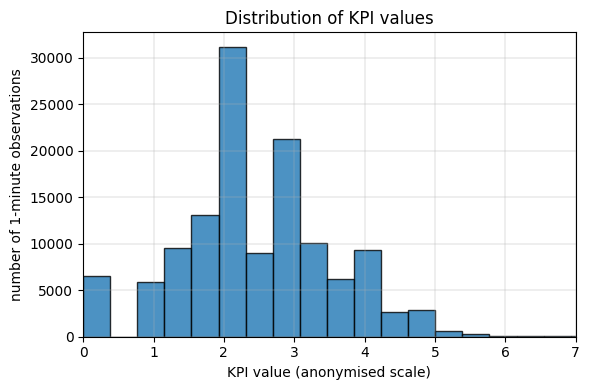

In [67]:
fig, ax = plt.subplots(figsize=(6, 4))

# Draw a histogram of KPI values
ax.hist(
    case_d_data["value"],
    bins=50,
    edgecolor="black",
    alpha=0.8 
)

ax.set_title("Distribution of KPI values")
ax.set_xlabel("KPI value (anonymised scale)")
ax.set_ylabel("number of 1-minute observations")  

# Focus on the region where most values exist
ax.set_xlim(0, 7)

ax.grid(True, linewidth=0.3)
plt.tight_layout()
plt.show()


### Histogram of KPI values

- The histogram shows the distribution of all 1-minute KPI values for Case Study D. Most observations fall between roughly 1.5 and 3.5 on the anonymised scale, with a strong concentration around 2–3. This confirms the presence of a well-defined normal operating band.

- The distribution is unimodal and slightly right-skewed: there is a clear peak near 2, followed by gradually decreasing counts as values move towards 4–5. Only a small number of observations occur above about 5–6, indicating that large excursions beyond the central band are rare.

- These patterns are consistent with the summary statistics (Q1 ≈ 1.92, median ≈ 2.25, Q3 ≈ 3.08) and support the interpretation of this KPI as a mostly stable operational metric with occasional extreme deviations. The central mass describes typical behaviour that models need to learn, while the sparse upper tail corresponds to anomaly events that diffusion-based detectors and baseline methods are expected to identify.


### Full-series plot with anomalies highlighted

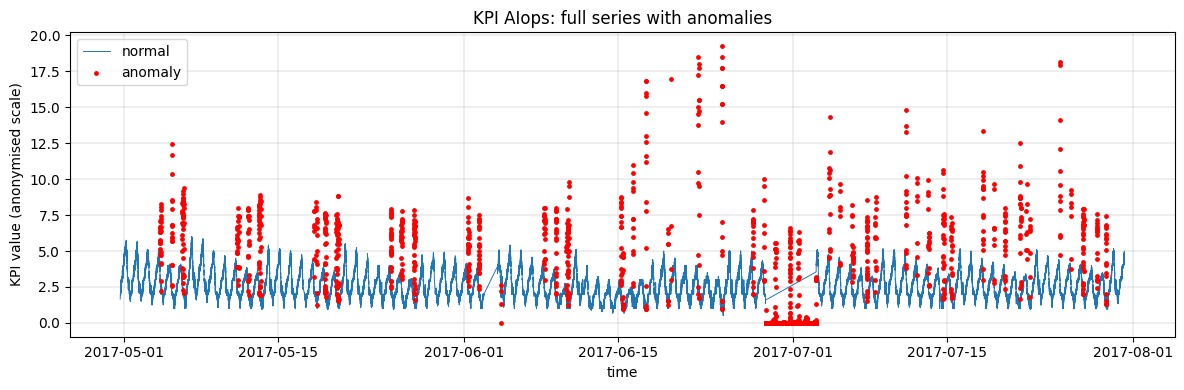

In [17]:
# Separate normal points and anomalies for plotting
normal_points = case_d_data[case_d_data["label"] == 0]
anomaly_points = case_d_data[case_d_data["label"] == 1]

# Create a figure and a single axes object for the plot
fig, ax = plt.subplots(figsize=(12, 4))

# Plot normal behaviour as a line
ax.plot(
    normal_points["time"],
    normal_points["value"],
    linewidth=0.7,
    label="normal",
)

# Overlay anomalous points as red markers
ax.scatter(
    anomaly_points["time"],
    anomaly_points["value"],
    s=6,
    color="red",
    label="anomaly",
    zorder=3 
)

ax.set_title("KPI AIops: full series with anomalies")
ax.set_xlabel("time")
ax.set_ylabel("KPI value (anonymised scale)")
ax.legend()
ax.grid(True, linewidth=0.3)

plt.tight_layout()
plt.show()


### Full-series plot with anomalies highlighted

- The blue curve shows the full KPI time series across the entire observation period. Because the y-axis is scaled to include extreme anomaly values (up to around 19 on the anonymised scale), the normal daily oscillations appear compressed near the lower part of the plot. The summary statistics and the zoomed view in the next figure show that most normal values lie in a central band roughly between 2 and 3, even though this band is not visually dominant at the full scale.

- The red points represent anomalous observations. These anomalies include:
  - isolated high spikes that rise far above the main cluster of blue values,
  - low dips close to zero, and
  - groups of consecutive timestamps where many points are labelled anomalous.
  This mixture indicates that anomalies are not limited to occasional outliers but also occur as short bursts and longer disturbed periods.

- The time axis shows that anomaly activity is not uniform over the series. Early in the period, anomalies appear as relatively short bursts on top of a visible daily pattern. In the middle portion, the density of anomalous points increases substantially and the daily waveform is more difficult to distinguish, indicating an extended unstable regime. Later in the series, anomalies remain more frequent than at the start and continue to appear as bursts superimposed on the daily pattern.

- This full-series view is useful for understanding the overall scale and timing of anomalies in relation to the entire KPI history. The figure highlights the presence of extreme events and sustained unstable periods, which are important for later analysis of concept drift and regime changes when comparing diffusion-based anomaly detectors with baseline methods. The zoomed plot that follows provides a clearer view of the normal operating band and the relative size of anomalies within that band.


### Zoomed view on the main operating band

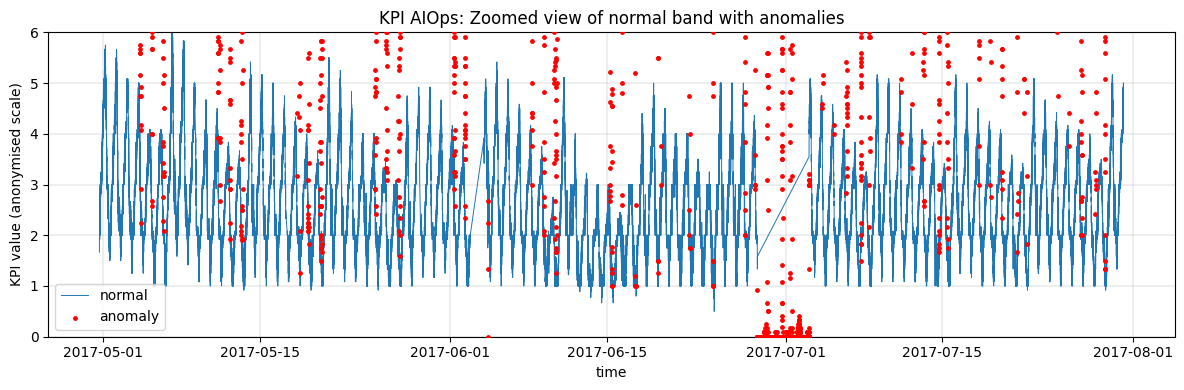

In [21]:
# Create a figure and a single axes object for the plot
fig, ax = plt.subplots(figsize=(12, 4))

# Plot normal behaviour as a line
ax.plot(
    normal_points["time"],
    normal_points["value"],
    linewidth=0.7,
    label="normal",
)

# Overlay anomalous points as red markers
ax.scatter(
    anomaly_points["time"],
    anomaly_points["value"],
    s=6,
    color="red",
    label="anomaly",
    zorder=3
)

ax.set_title("KPI AIOps: Zoomed view of normal band with anomalies")
ax.set_xlabel("time")
ax.set_ylabel("KPI value (anonymised scale)")

# Focus on the range where normal behaviour lives
ax.set_ylim(0, 6)

ax.legend()
ax.grid(True, linewidth=0.3)

plt.tight_layout()
plt.show()


### Zoomed view of the normal operating band with anomalies

- Limiting the y-axis to the range 0–6 makes the normal daily pattern of the KPI more visible. The blue curve shows repeated cycles where values typically fluctuate between roughly 1.5 and 4.5 on the anonymised scale, with many points in the 2–3 region. This is consistent with the summary statistics and confirms the presence of a well-defined normal operating band.

- The red markers highlight anomalous observations relative to this band. Two main types of deviation are visible:
  - high anomalies that rise clearly above the normal daily peaks, and  
  - low anomalies where values fall close to 0–1 and the usual daily waveform is disrupted, particularly around early July.

- The temporal evolution of the plot indicates changes in regime. Early in the series, daily cycles are regular and anomalies appear as short bursts on top of the normal pattern. In the middle part of the series, the density of anomalous points increases and the normal waveform is heavily disturbed, creating a sustained unstable period. Later in the series, the daily pattern reappears but remains interspersed with frequent anomaly bursts.

- These features are important for the overall research objective. The stable central band provides a clear target for modelling normal behaviour, while the mixture of positive and negative deviations, together with the shift from a quiet regime to a more unstable one, supports analysis of concept drift and regime changes. This makes Case Study D a suitable setting for comparing diffusion-based anomaly detectors with baseline methods on a realistic operational KPI.


### Class balance for KPI AIOps (normal vs anomaly)


In [24]:
# Count how many points fall into each label
label_counts = (
    case_d_data["label"]
    .value_counts()
    .rename(index={0: "normal", 1: "anomaly"})
    .to_frame(name="count")
    .reset_index()
    .rename(columns={"index": "class"})
)

# Add the fraction of the series each class represents
total_points = len(case_d_data)
label_counts["fraction of class"] = label_counts["count"] / total_points

label_counts


,label,count,fraction of class
0,normal,121369,0.94059
1,anomaly,7666,0.05941


### Class balance for KPI AIOps dataset

- The KPI series contains 129 035 labelled points in total:
  - 121 369 normal points (≈ 94.1% of the series)
  - 7 666 anomalous points (≈ 5.9% of the series)

- The data are therefore strongly imbalanced, with normal behaviour dominating the time axis. At the same time, the anomaly class is represented by several thousand points, which is substantially richer than datasets that contain only a few isolated anomalies.

- This pattern is consistent with the intended application: operational KPIs where faults and incidents are relatively rare compared with normal behaviour. For the later modelling stages, this implies that labels are most useful for evaluation and event analysis, while anomaly detectors should be designed to operate under class imbalance. The imbalance also motivates the use of metrics that focus on rare-event performance (such as precision, recall and event-level scores) rather than accuracy alone when comparing diffusion-based anomaly detectors with baseline methods.


### Daily anomaly ratio over time

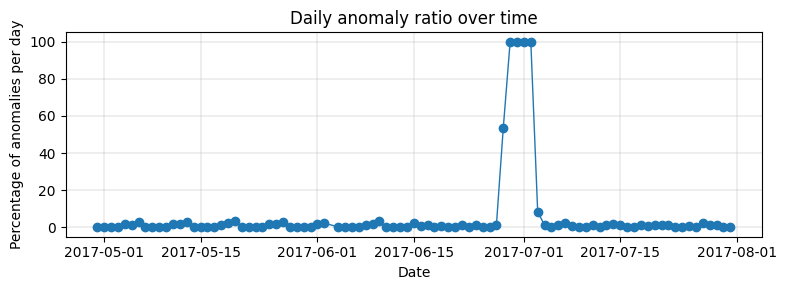

In [77]:
# Derive a pure date column (without time of day)
case_d_data["date"] = case_d_data["time"].dt.date

# Compute the fraction of anomalies per day
daily_anomaly_ratio = (
    case_d_data
    .groupby("date")["label"]
    .mean()
    .to_frame(name="anomaly_ratio")
    .reset_index()
)

# Plot anomaly ratio over calendar time
fig, axis = plt.subplots(figsize=(8, 3))

axis.plot(
    daily_anomaly_ratio["date"],
    daily_anomaly_ratio["anomaly_ratio"] * 100,
    marker="o",
    linewidth=1.0,
)

axis.set_title("Daily anomaly ratio over time")
axis.set_xlabel("Date")
axis.set_ylabel("Percentage of anomalies per day")
axis.grid(True, linewidth=0.3)

plt.tight_layout()
plt.show()


### Daily anomaly ratio over time

- The plot shows the fraction of anomalous points for each calendar day in the Case Study D time series. For most of the period between late April and the end of July, the daily anomaly ratio remains close to zero, indicating that almost all 1-minute observations on those days are labelled as normal.

- Around the end of June and the beginning of July, the daily anomaly ratio increases sharply, reaching values close to 1.0 on some days. Ratios near 1.0 indicate days where almost every minute is labelled anomalous. This marks a sustained incident period rather than isolated outliers.

- After this high-activity window, the anomaly ratio returns to low levels, with only occasional smaller increases. This pattern suggests a transition from a stable regime to a highly unstable regime and then back towards a more normal operating state.

- For the purposes of the research project, this daily view provides clear evidence of non-stationary anomaly behaviour and regime changes in the KPI. It highlights a specific high-anomaly window that is well suited for window-based evaluation and concept drift analysis when comparing diffusion-based anomaly detectors with baseline methods.


### Sampling interval and time axis checks

In [40]:
# Differences between consecutive timestamps (in seconds)
time_differences = case_d_data["time"].diff().dt.total_seconds().dropna()

# How often each time step occurs
time_difference_counts = (
    time_differences.value_counts()
    .sort_index()
    .to_frame(name="count")
    .reset_index()
    .rename(columns={"index": "time_difference_seconds"})
)

time_difference_counts_head = time_difference_counts.head(10)
time_difference_counts_head


,time,count
0,60.0,128994
1,120.0,10
2,180.0,10
3,240.0,7
4,600.0,1
5,3660.0,8
6,7260.0,2
7,12120.0,1
8,106500.0,1


### Sampling interval and time-axis regularity

- The time differences between consecutive observations show a dominant step of **60 seconds** (1 minute), with 128 994 occurrences. This indicates that the KPI is effectively sampled at a one-minute interval.

- A small number of larger gaps are present, including 120, 180 and 240 seconds (2–4 minutes), and a few isolated gaps of 600 seconds (10 minutes), 3 660 seconds (≈ 1 hour), 7 260 seconds (≈ 2 hours), 12 120 seconds (≈ 3.4 hours) and 106 500 seconds (≈ 29.6 hours). These gaps correspond to short periods where one or more expected readings are missing.

- Overall, the series behaves as a regularly sampled one-minute operational KPI with a handful of missing blocks. This regular structure is suitable for time-series anomaly detection and aligns with common monitoring setups. The rare longer gaps can be recorded as potential missing periods in preprocessing but are unlikely to affect the general character of the series.


In [41]:
# Summary table for time differences (in seconds)
time_difference_summary = (
    time_differences
    .describe(percentiles=[0.25, 0.5, 0.75])  # keep it simple
    .rename({
        "25%": "Q1 (25%)",
        "50%": "Median (50%)",
        "75%": "Q3 (75%)"
    })
    .to_frame(name="time difference seconds")
    .reset_index()
    .rename(columns={"index": "statistic"})
)

time_difference_summary


,statistic,time difference seconds
0,count,129034.000000
1,mean,61.281058
2,std,300.900148
3,min,60.000000
4,Q1 (25%),60.000000
5,Median (50%),60.000000
6,Q3 (75%),60.000000
7,max,106500.000000


### Summary of time differences between observations

- The time differences between consecutive observations were summarised using standard descriptive statistics. The minimum, first quartile (Q1), median and third quartile (Q3) are all equal to 60 seconds. This indicates that at least 75% of the time gaps are exactly one minute, confirming that the KPI behaves as an almost perfectly regular 1-minute time series.

- The mean time difference is approximately 61.3 seconds and the standard deviation is about 300.9 seconds. The mean being close to 60 seconds is consistent with the dominant one-minute step, while the relatively large standard deviation reflects the presence of a small number of long gaps rather than widespread irregularity.

- The maximum time difference is 106 500 seconds (around 29.6 hours), which matches the rare large gaps seen in the time-difference counts. These values reinforce the conclusion that the series can be treated as a regularly sampled 1-minute operational KPI with a few missing blocks, a structure that fits typical monitoring scenarios and is suitable for time-series anomaly detection in this case study.


### Preprocessing and modelling notes for Case Study D

- Source and structure  
  - Case Study D uses a single KPI from the AIOps 2018 anomaly detection dataset, extracted from the stacked `train.csv` file by filtering on `KPI ID = da403e4e3f87c9e0`.  
  - The series contains 129 035 labelled observations on an anonymised value scale.

- Time index and sampling  
  - Timestamps are stored as pandas datetimes and sorted in ascending order.  
  - Time-difference analysis shows a dominant step of 60 seconds, with at least 75% of gaps equal to one minute and a small number of longer gaps caused by missing blocks.  
  - For modelling, the series can be treated as a regular 1-minute operational KPI with a few short missing periods that can either be left as gaps or flagged if required.

- Value scaling and features  
  - The histogram and summary statistics indicate a normal operating band with most values between roughly 2 and 3, and occasional excursions down to 0 and up to about 19.  
  - Values should be standardised or normalised before fitting diffusion models and baseline methods (e.g. z-score based on the training portion of this series).  
  - Optional time-based features (such as hour-of-day or day-of-week) can be derived from the timestamp if needed, but the core analysis can treat the KPI as a univariate sequence.

- Labels and class imbalance  
  - The `label` column marks normal points (0) and anomalies (1). Normal points account for approximately 94.1% of the series and anomalies for about 5.9%, so the data are strongly imbalanced but include several thousand anomalous observations.  
  - Labels are intended primarily for evaluation and event analysis rather than for training a balanced supervised classifier.

- Anomaly and regime structure  
  - Under normal conditions the series shows a regular daily pattern within the central value band. Anomalies appear as high spikes, low dips and denser bursts that disrupt this pattern.  
  - The daily anomaly ratio over time reveals a mostly quiet early period, a high-anomaly incident window around late June / early July with ratios close to 1.0 on some days, and a later period where anomaly activity returns to low levels. This behaviour supports analysis of concept drift and regime changes.

- Role in the overall study  
  - This KPI provides a realistic operational case study for comparing diffusion-based anomaly detectors with baseline methods (Isolation Forest, One-Class SVM, Autoencoder, and any additional simple baselines).  
  - Evaluation should emphasise metrics that handle imbalance and temporal structure, including event-level or window-based measures, to capture how well each method identifies anomalous episodes over time rather than only point-wise accuracy.
